In [ ]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


In [ ]:
import os
os.listdir()

['.config', 'spam.csv', 'sample_data']

Dataset Loaded Successfully
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Naive Bayes
Accuracy: 0.968609865470852

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115


Random Forest
Accuracy: 0.9730941704035875

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.80      0.89      

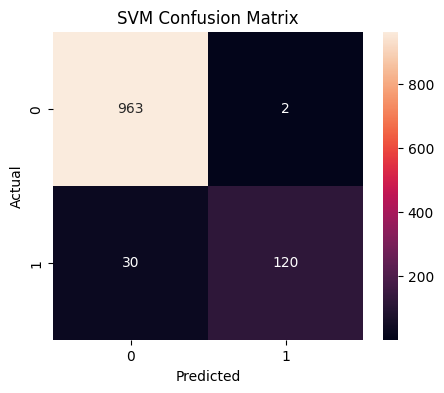

/tmp/ipykernel_890/1486871813.py:158: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 640x480 with 0 Axes>

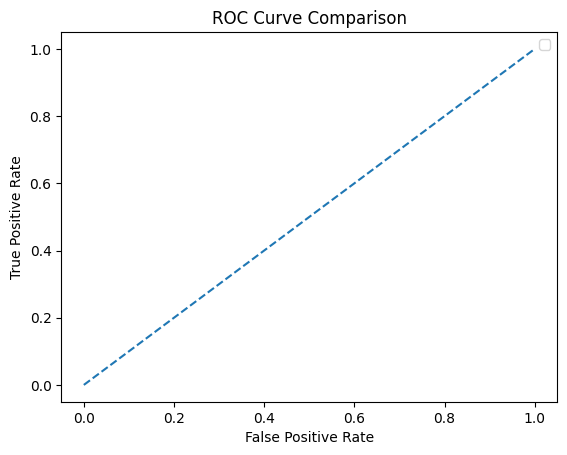

<Figure size 640x480 with 0 Axes>

In [ ]:
# ===============================
# SPAM DETECTION PROJECT
# CSV VERSION (spam.csv)
# ===============================

# Import libraries
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# LOAD DATASET
# ===============================

df = pd.read_csv('spam.csv', encoding='latin-1')

# Keep only needed columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

print("Dataset Loaded Successfully")
print(df.head())

# ===============================
# CLEAN TEXT
# ===============================

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['message'] = df['message'].apply(clean_text)

# ===============================
# LABEL ENCODING
# ===============================

df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

# ===============================
# TRAIN TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    df['message'],
    df['label'],
    test_size=0.2,
    random_state=42
)

# ===============================
# TF-IDF
# ===============================

vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# ===============================
# MODELS
# ===============================

models = {
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

results = {}

# ===============================
# TRAIN + EVALUATE
# ===============================

for name, model in models.items():

    print("\n=======================")
    print(name)
    print("=======================")

    model.fit(X_train_tfidf, y_train)

    predictions = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, predictions)

    print("Accuracy:", accuracy)

    print("\nClassification Report:")
    print(classification_report(y_test, predictions))


  # Confusion Matrix
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title(name + " Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

plt.savefig("roc_curve_comparison.png", bbox_inches='tight')

# ===============================
# ROC CURVE COMPARISON
# ===============================

plt.figure()

for name in results:

    fpr, tpr, roc_auc = results[name]

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

plt.savefig("roc_curve_comparison.png")

plt.savefig(f"{name}_confusion_matrix.png")
